<a href="https://colab.research.google.com/github/siddharth10-dev/machine_learning_practs/blob/main/DecisionTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import python

In [5]:
%matplotlib inline

In [9]:
df=pd.read_csv('kyphosis.csv')

In [10]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


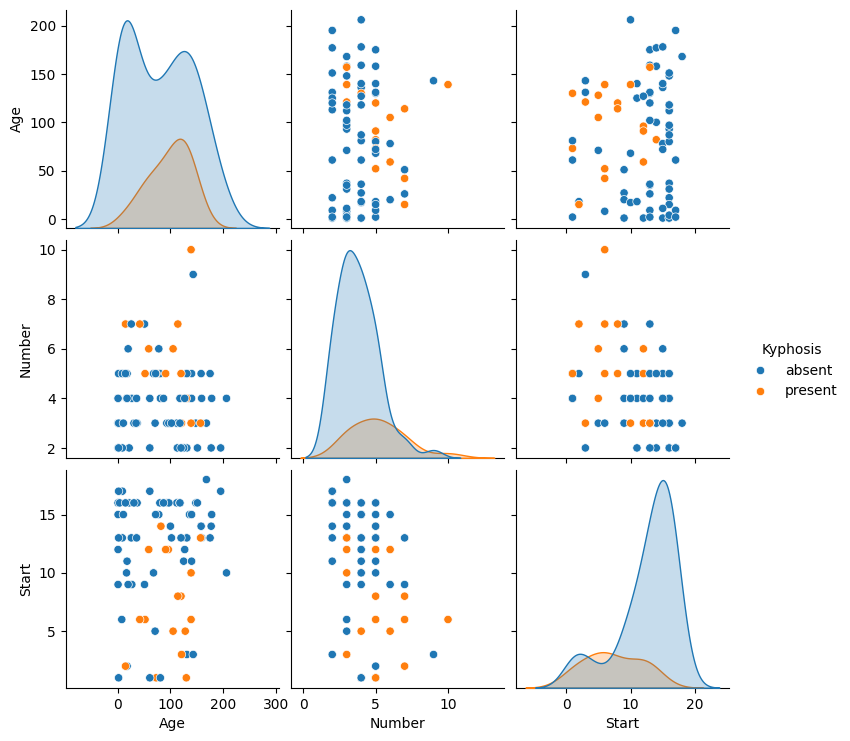

In [11]:
sns.pairplot(df,hue='Kyphosis')

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X=df.drop('Kyphosis',axis=1)
y=df['Kyphosis']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
dtree=DecisionTreeClassifier()

In [22]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [23]:
predictions=dtree.predict(X_test)

In [24]:
from sklearn.metrics import classification_report,confusion_matrix

In [25]:
print(confusion_matrix(y_test,predictions))
print('\n')
print(classification_report(y_test,predictions))

[[12  5]
 [ 6  2]]


              precision    recall  f1-score   support

      absent       0.67      0.71      0.69        17
     present       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25



In [26]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rforest=RandomForestClassifier(n_estimators=100)
rforest.fit(X_train, y_train)

RandomForestClassifier()

In [30]:
predictions=rforest.predict(X_test)

In [31]:
print(confusion_matrix(y_test,predictions))
print('\n')
print(classification_report(y_test,predictions))

[[17  0]
 [ 6  2]]


              precision    recall  f1-score   support

      absent       0.74      1.00      0.85        17
     present       1.00      0.25      0.40         8

    accuracy                           0.76        25
   macro avg       0.87      0.62      0.62        25
weighted avg       0.82      0.76      0.71        25



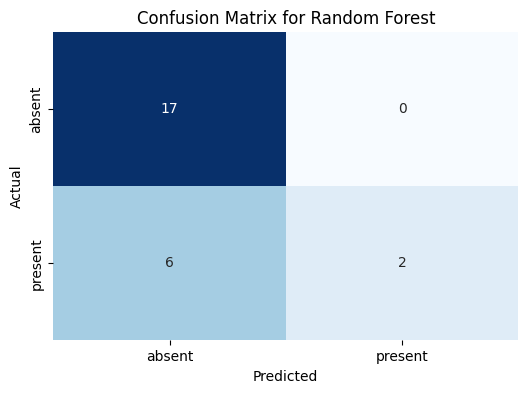

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['absent', 'present'], yticklabels=['absent', 'present'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [34]:
from io import StringIO
dot_data = StringIO()

In [39]:
import sys

try:
    import graphviz
except ImportError:
    print("Installing graphviz...")
    !{sys.executable} -m pip install graphviz
    import graphviz

In [40]:
from sklearn import tree

feature_names = X.columns.tolist()
class_names = dtree.classes_.tolist()

tree.export_graphviz(dtree,
                    out_file=dot_data,
                    feature_names=feature_names,
                    class_names=[str(x) for x in class_names],
                    filled=True, rounded=True,
                    special_characters=True)

In [41]:
graph = graphviz.Source(dot_data.getvalue())
graph.render("decision_tree_visualization", format="png", cleanup=True)
print("Decision tree visualization saved as decision_tree_visualization.png")

Decision tree visualization saved as decision_tree_visualization.png


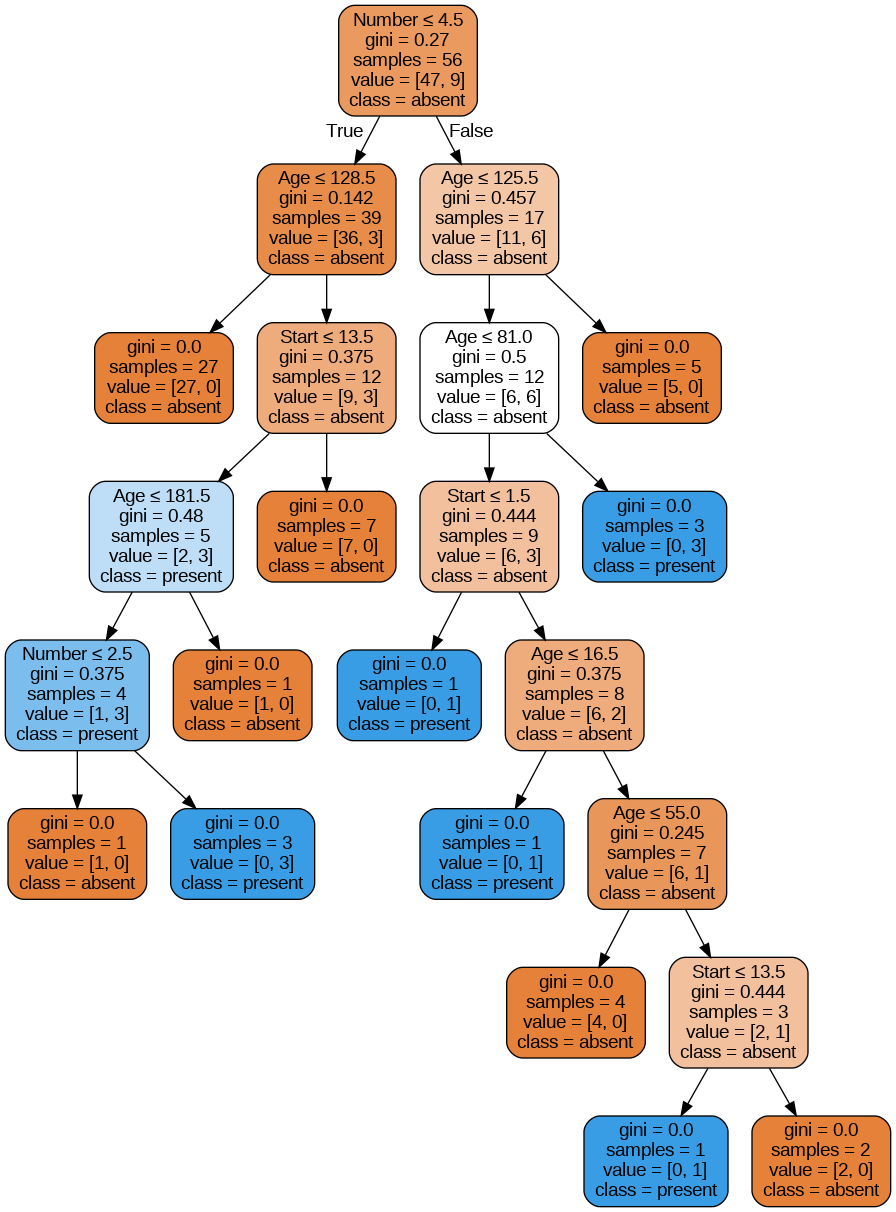

In [43]:
from IPython.display import Image
Image(filename='decision_tree_visualization.png')